# Data Analytics - Exercise 8

Note that the tasks should be submitted as an HTML file, showing both the contents of the code cells and the outputs. You can get the notebook as an HTML file by selecting File -> Download as -> HTML. The answers to the tasks can be done in one or more code cells.

**Student Name**: Jayani Kothalawala

**Student Number**: AD9680


## Subplots

To make it easier to compare plots, it is useful to learn how to group them side by side and one below the other. In this task, we will learn how to create a pie chart and place two plots side by side.

Read the dataset 'cybersecurity_attacks.csv' into a DataFrame from the URL https://student.labranet.jamk.fi/~ajota/Datasets/cybersecurity_attacks.csv.

Create the following plots in the same figure side by side, as shown in the model below.

- Visualize the percentage shares of different attack types in the dataset in a pie chart.
- Visualize the monthly counts of the attack type 'Malware' in a bar chart for the year 2022. (Hint: First create new columns "Year" and "Month" from the "Timestamp" column and then start filtering and grouping the data using these.)

![malli3](https://student.labranet.jamk.fi/~ajota/Data-analytics/images/malli_harjoitus8_hyokkaystyypit_ja_lukumaarat_kuukausittain.png)

Scoring: 1 p

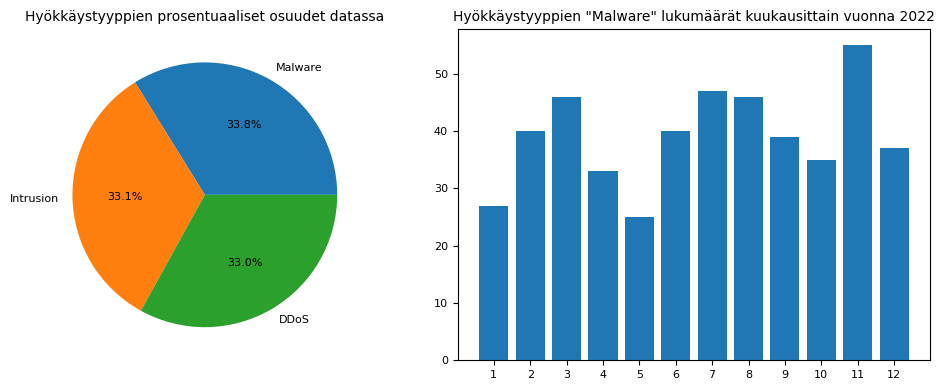

In [297]:
# Answer
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://student.labranet.jamk.fi/~ajota/Datasets/cybersecurity_attacks.csv', index_col=0)

result = df.groupby(["Attack Type"]).size().sort_index()
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
malware = df[(df["Attack Type"]=="Malware") & (df["Year"]==2022)]
monthly_malware = malware.groupby(["Month"]).size()


# Make figure and axes
fig, axs = plt.subplots(1,2,figsize=(10, 4))
ax1, ax2 = axs
result = result.reindex(["Malware", "Intrusion", "DDoS"])
labels = result.index 
# A standard pie plot
ax1.pie(result, autopct='%1.1f%%', labels=labels, textprops={'fontsize': 8})
ax1.set_title("Hyökkäystyyppien prosentuaaliset osuudet datassa",fontsize=10)


ax2.bar(monthly_malware.index,monthly_malware.values)
ax2.set_title("Hyökkäystyyppien \"Malware\" lukumäärät kuukausittain vuonna 2022",fontsize=10)
ax2.set_xticks(range(1, 13, 1))
ax2.tick_params(axis='x', labelsize=8)  # x-axis tick labels
ax2.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()



## Resampling

Sometimes time series data lacks an appropriate sampling interval to be sensibly visualized. In such cases, resampling can be tried.

The file 'dos_attack_unsw_nb15.csv' contains synthetic data created for research purposes, describing DoS attacks. You can read the data from the URL 'https://student.labranet.jamk.fi/~ajota/Datasets/dos_attack_unsw_nb15.csv'.

Visualize the number of connections over time. You can use the 'record start time' column for time and calculate the number of connections using, for example, the 'Source IP address' column.

Consider/test a reasonable sampling interval (5 s, 10 s, 30 s, 60 s) for visualizing the number of connections.

Below is an example of resampling at 30-second intervals.
![malli](https://student.labranet.jamk.fi/~ajota/Data-analytics/images/malli_uudelleen_naytteistaminen.png)


Scoring: 1 p

In [298]:
import pandas as pd
import matplotlib.dates as mdates
url = 'https://student.labranet.jamk.fi/~ajota/Datasets/dos_attack_unsw_nb15.csv'
df_dos = pd.read_csv(url, index_col=0)
df_dos

,Source IP address,Source port number,Destination IP address,Destination port number,Transaction protocol,"Indicates to the state and its dependent protocol, e.g. ACC, CLO, CON, ECO, ECR, FIN, INT, MAS, PAR, REQ, RST, TST, TXD, URH, URN, and (-) (if not used state)",Record total duration,Source to destination transaction bytes,Destination to source transaction bytes,Source to destination time to live value,...,No of flows that has a command in ftp session.,No. of connections that contain the same service (14) and source address (1) in 100 connections according to the last time (26).,No. of connections that contain the same service (14) and destination address (3) in 100 connections according to the last time (26).,No. of connections of the same destination address (3) in 100 connections according to the last time (26).,No. of connections of the same source address (1) in 100 connections according to the last time (26).,No of connections of the same source address (1) and the destination port (4) in 100 connections according to the last time (26).,No of connections of the same destination address (3) and the source port (2) in 100 connections according to the last time (26).,No of connections of the same source (1) and the destination (3) address in in 100 connections according to the last time (26).,"The name of each attack category. In this data set , nine categories e.g. Fuzzers, Analysis, Backdoors, DoS Exploits, Generic, Reconnaissance, Shellcode and Worms",0 for normal and 1 for attack records
0,175.45.176.0,39500,149.171.126.15,80,tcp,FIN,0.177449,1214,268,254,...,0,5,2,1,1,1,1,1,DoS,1
1,175.45.176.0,23910,149.171.126.15,80,tcp,FIN,2.592910,2082,268,254,...,0,5,2,1,2,2,1,1,DoS,1
2,175.45.176.1,12940,149.171.126.16,80,tcp,FIN,0.268272,878,1002,62,...,0,3,1,1,1,1,1,1,DoS,1
3,175.45.176.0,14324,149.171.126.13,502,tcp,FIN,0.214066,468,268,254,...,0,1,1,1,1,1,1,1,DoS,1
4,175.45.176.2,6551,149.171.126.12,162,udp,INT,0.000021,136,0,254,...,0,1,1,1,1,1,1,1,DoS,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1162,175.45.176.0,35369,149.171.126.19,80,tcp,FIN,0.289723,864,1390,254,...,0,2,1,1,1,1,1,1,DoS,1
1163,175.45.176.2,24841,149.171.126.18,25,tcp,FIN,1.012112,806,1096,254,...,0,5,2,1,2,1,1,1,DoS,1
1164,175.45.176.1,27333,149.171.126.16,143,tcp,FIN,1.206070,1010,4962,62,...,0,2,1,1,1,1,1,1,DoS,1
1165,175.45.176.3,25474,149.171.126.10,88,udp,CON,0.169691,2132,1512,254,...,0,8,1,1,3,1,1,1,DoS,1


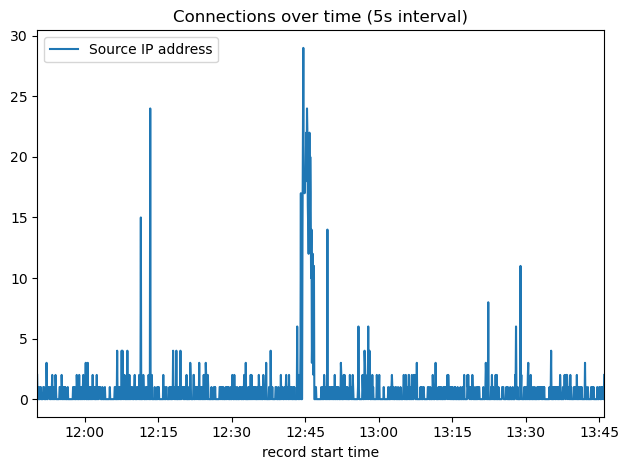

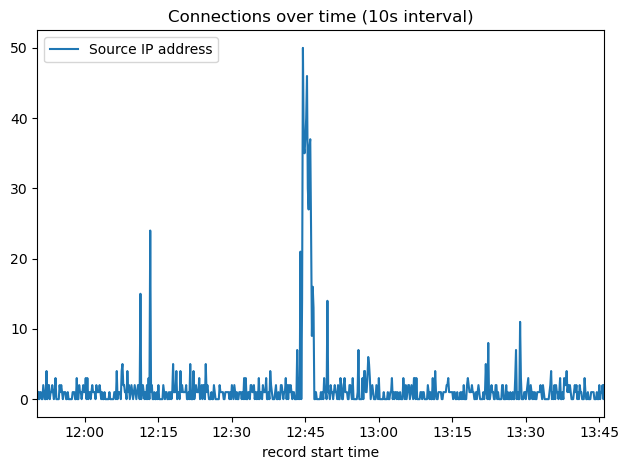

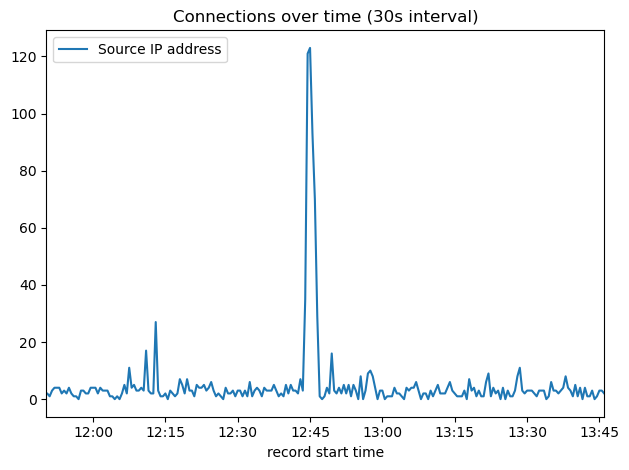

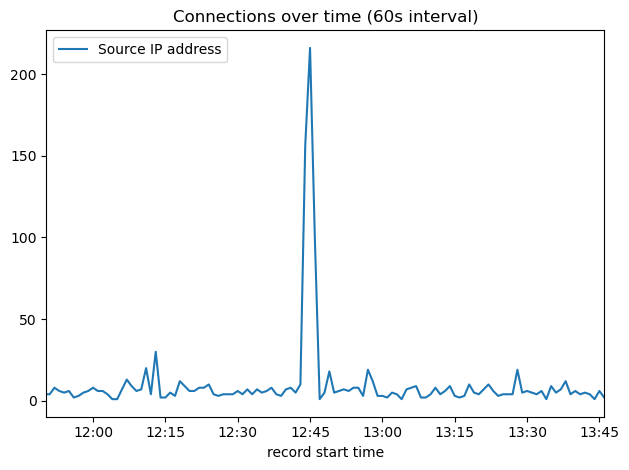

In [299]:
# Answer
import matplotlib.dates as mdates
# 1. Convert timestamp column
df_dos["record start time"] = pd.to_datetime(df_dos["record start time"])

# 2. Set it as index
df_dos = df_dos.set_index("record start time")



def plot_connections(interval):
    # Resample to count connections
    
    connections = df_dos["Source IP address"].resample(interval).count()
    
   

    # Plot
    plt.figure()
    plt.plot(connections.index, connections.values)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.legend(["Source IP address"], loc="upper left")
    plt.title(f"Connections over time ({interval} interval)")
    plt.xlabel("record start time")
    plt.xlim([df_dos.index.min(), df_dos.index.max()])
    plt.tight_layout()
    plt.show()


for interval in ["5s", "10s", "30s", "60s"]:
    plot_connections(interval)

# Visualizing Time Series Data

Read the file 'rba-dataset_january2021.csv' into a dataframe from the URL 'https://student.labranet.jamk.fi/~ajota/Datasets/rba-dataset_january2021.csv'. (If the amount of data proves to be an insurmountable problem, you can read only a part of the data. The original dataset and descriptions of the information can be found on Kaggle at https://www.kaggle.com/datasets/dasgroup/rba-dataset)

Visualize the number of successful and unsuccessful login attempts daily on an hourly basis according to the example below. The X-axis should show the date and time. The formatting of the date and time can differ from the example.

![malli](https://student.labranet.jamk.fi/~ajota/Data-analytics/images/malli_rba_kirjautumisten_maara.png)

Although this is a synthetic dataset and the amount of data has been significantly reduced for this task (and thus the data may not fully correspond to reality), consider the following questions:

- Do the login attempts concentrate on certain days or hours? What explains this?
- Are there any observable trends or seasonal variations in the data?
- How do the peaks of successful and unsuccessful login attempts compare to each other? Is there a natural explanation for your observation?
- What could explain the large number of unsuccessful login attempts at the beginning of the chart (with hourly variations and consistently elevated numbers compared to the later period shown in the chart)? 

Scoring: Graph 1 p + explanation 1 p

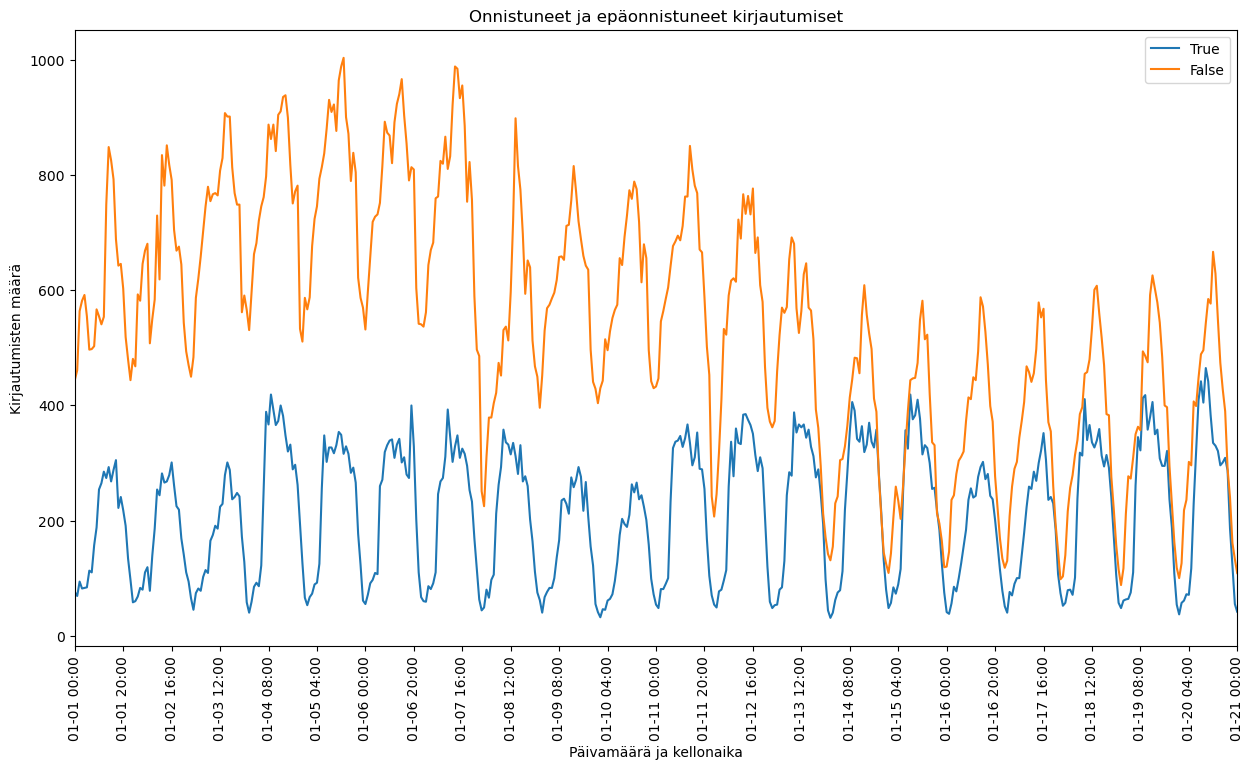

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
df_rpa = pd.read_csv('https://student.labranet.jamk.fi/~ajota/Datasets/rba-dataset_january2021.csv', index_col=0)
df_rpa["Login Timestamp"] = pd.to_datetime(df_rpa["Login Timestamp"])
df_rpa = df_rpa.set_index("Login Timestamp")
success = df_rpa[df_rpa["Login Successful"] == True]
failure = df_rpa[df_rpa["Login Successful"] == False]

success_hourly = success.resample("1h").size()
failure_hourly = failure.resample("1h").size()


plt.figure(figsize=(15,8))

plt.plot(success_hourly, label="True")
plt.plot(failure_hourly, label="False")



plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=20))




start = pd.Timestamp("2021-01-01 00:00")
end   = pd.Timestamp("2021-01-21 00:00")
plt.gca().set_xlim(start,end)
plt.title("Onnistuneet ja epäonnistuneet kirjautumiset")
plt.xlabel("Päivamäärä ja kellonaika")

plt.ylabel("Kirjautumisten määrä")
plt.legend()

plt.xticks(rotation=90)

plt.show()


- Do the login attempts concentrate on certain days or hours? What explains this?
- Yes, login attempts concentrate clearly around specific hours of the day. Successful logins show a repeating daily pattern and it shows higher during working hours of the day. it is lower during the night time. It suggests a normal behaviour of the users log. Users log in during work hours and and few successful logins only happen in late night. Unsuccessful attempts are showing higher number than succeesful logins but they have no clear pattern like successful logins. False logins also concentrate for working hours, that it shows higher number of attempts on mostly working hours and fewer unsuccessful logins at night. It also shows a little similar pattern to succeesful logins but it shows higher number. Unsuccessful login attempts show a lower number of attempts after 01-07 at 16:00.Successfu logins and unsuccessful login attempts do not show a concentration on a specific date but concentrate to mostly for working hours between 08:00 to 16:00.  

- Are there any observable trends or seasonal variations in the data?
- Yes, There is a clear downward trend over time for unsuccessful login attempts. At the beginning 01-01 to 01-07 it shows a very high number of failed attempts. After 01-07 the failed attempts decrease and stabillize. The successful logins shows an average similar pattern daily and it repeats peaks and dips every 24 hours. it is daily seasonality.

- How do the peaks of successful and unsuccessful login attempts compare to each other? Is there a natural explanation for your observation?
- Unsuccessful login peaks are much higher at the beginning of the chart. Over the time the failed attempts decrease and successful attempts remain relatively stable. So in early period failure dominates but in later period it becomes more stable and balanced with successful login attempts. Failed attempts may include brute force attacks or incorrect login attempts while successful logins reflects real users showing more stable behaviour. but at later period these incorrect logins and brute force attacks have been reduced.

- What could explain the large number of unsuccessful login attempts at the beginning of the chart (with hourly variations and consistently elevated numbers compared to the later period shown in the chart)? 
- The beginning shows high volume, frequent spikes and consistently elevated failures. They show high likely that the system may have been under attack initially and it maybe brute force attack, thus it failed at initial days. it may have run automated scripts trying many passwords that caused high and noisy failed login counts. But in later on the month the attack may have been mitigated with firewall rate limiting and blocking IPs, then system stabillized after few days and protection reduced failed attempts later.